In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/20
    print("準備完了！このまま下のセルを実行できます。")


# 第20章 拡散モデル (Diffusion Models)
# 20.3 スコアマッチング (Score Matching)

本ノートブックでは、『深層学習：基礎と概念 (Christopher M. Bishop & Hugh Bishop 著, Springer 2024)』第20章「拡散モデル」の第3節「スコアマッチング (Score Matching)」の数学的基礎、正則化定数を要しないスコア推定、デノイジングスコアマッチング、焼きなましランジュバン動力学、および連続時間確率微分方程式（SDE / ODE）の統一的枠組みを徹底解説します。

---

## 本節のアジェンダと網羅する小節
1. **20.3.1 スコア損失関数 (Score loss function)**
   - スコア関数 $\mathbf{s}(\mathbf{x}) = \nabla_{\mathbf{x}} \ln p(\mathbf{x})$ の定義と分配関数 $Z$ からの独立性 (式 20.21)
   - 明示的スコアマッチング損失 (Explicit Score Matching, 式 20.22)
   - ガウスの発散定理（部分積分）による陰的スコアマッチング (Implicit Score Matching, 式 20.23)
2. **20.3.2 修正スコア損失 (Modified score loss)**
   - 摂動ガウスカーネルとデノイジングスコアマッチング (Vincent 2011, 式 20.24 〜 20.26)
   - 拡散モデルにおけるノイズ予測とスコアベクトルの厳密な等価関係
3. **20.3.3 ノイズ分散 (Noise variance)**
   - 多重ノイズスケールと低密度領域におけるスコア推定の安定化 (Song & Ermon 2019, 式 20.27)
   - 焼きなましランジュバン動力学 (Annealed Langevin Dynamics, 式 20.28)
4. **20.3.4 確率微分方程式 (Stochastic differential equations)**
   - 連続時間前向き SDE (VP SDE, VE SDE, 式 20.29)
   - 逆時間確率微分方程式 (Reverse-time SDE, Anderson 1982, 式 20.30)
   - 決定論的確率流 ODE (Probability Flow ODE, 式 20.31) と正確な対数尤度計算


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.score_matching import (
    GaussianMixture2D,
    implicit_score_matching_loss,
    denoising_score_matching_loss,
    AnnealedLangevinDynamics,
    VPSDE,
    plot_score_vector_field_and_mixture,
)

setup_style()
print("第20章 スコアマッチングモジュールが正常に読み込まれました。")


第20章 スコアマッチングモジュールが正常に読み込まれました。


---

### 20.3.1 スコア損失関数 (Score loss function)

#### 1. スコア関数の定義と分配関数の消去
確率分布 $p(\mathbf{x})$ に対する**スコア関数（Score Function）**は、対数確率密度の空間勾配ベクトルとして定義されます：

$$
\mathbf{s}(\mathbf{x}) \equiv \nabla_{\mathbf{x}} \ln p(\mathbf{x}) \tag{20.21}
$$

未正規化の密度関数 $\tilde{p}(\mathbf{x})$ と計算困難な正規化定数（分配関数）$Z = \int \tilde{p}(\mathbf{x}) d\mathbf{x}$ を持つ分布 $p(\mathbf{x}) = \frac{\tilde{p}(\mathbf{x})}{Z}$ において、対数勾配をとると：

$$
\nabla_{\mathbf{x}} \ln p(\mathbf{x}) = \nabla_{\mathbf{x}} \left( \ln \tilde{p}(\mathbf{x}) - \ln Z \right) = \nabla_{\mathbf{x}} \ln \tilde{p}(\mathbf{x}) - \mathbf{0} = \nabla_{\mathbf{x}} \ln \tilde{p}(\mathbf{x})
$$

となり、**分配関数 $Z$ が完全に消去されます**。

#### 2. 明示的スコアマッチングから陰的スコアマッチングへの変形 (式 20.22, 20.23)
ニューラルネットワーク $\mathbf{s}(\mathbf{x}, \mathbf{w})$ を用いて真のスコア $\nabla_{\mathbf{x}} \ln p(\mathbf{x})$ を学習する理想的な損失関数は：

$$
J(\mathbf{w}) = \frac{1}{2} \int p(\mathbf{x}) \|\mathbf{s}(\mathbf{x}, \mathbf{w}) - \nabla_{\mathbf{x}} \ln p(\mathbf{x})\|^2 d\mathbf{x} \tag{20.22}
$$

二乗項を展開すると：
$$
J(\mathbf{w}) = \frac{1}{2} \int p(\mathbf{x}) \|\mathbf{s}(\mathbf{x}, \mathbf{w})\|^2 d\mathbf{x} - \int p(\mathbf{x}) \mathbf{s}(\mathbf{x}, \mathbf{w})^T \nabla_{\mathbf{x}} \ln p(\mathbf{x}) \, d\mathbf{x} + \text{const}
$$
第2項において $p(\mathbf{x}) \nabla_{\mathbf{x}} \ln p(\mathbf{x}) = \nabla_{\mathbf{x}} p(\mathbf{x})$ であるため：
$$
-\int \sum_{i=1}^D s_i(\mathbf{x}, \mathbf{w}) \frac{\partial p(\mathbf{x})}{\partial x_i} d\mathbf{x}
$$
無限遠で $p(\mathbf{x})\mathbf{s}(\mathbf{x}, \mathbf{w}) \to \mathbf{0}$ と仮定して部分積分（発散定理）を適用すると：
$$
= \int p(\mathbf{x}) \sum_{i=1}^D \frac{\partial s_i(\mathbf{x}, \mathbf{w})}{\partial x_i} d\mathbf{x} = \int p(\mathbf{x}) \operatorname{Tr}\left( \nabla_{\mathbf{x}} \mathbf{s}(\mathbf{x}, \mathbf{w}) \right) d\mathbf{x}
$$
これより、真のスコア関数を一切知ることなくデータサンプルのみから直接評価できる**陰的スコアマッチング（Implicit Score Matching: Hyvärinen 2005）**の目的関数が得られます：

$$
J(\mathbf{w}) = \int p(\mathbf{x}) \left[ \frac{1}{2}\|\mathbf{s}(\mathbf{x}, \mathbf{w})\|^2 + \operatorname{Tr}\left( \nabla_{\mathbf{x}} \mathbf{s}(\mathbf{x}, \mathbf{w}) \right) \right] d\mathbf{x} \tag{20.23}
$$


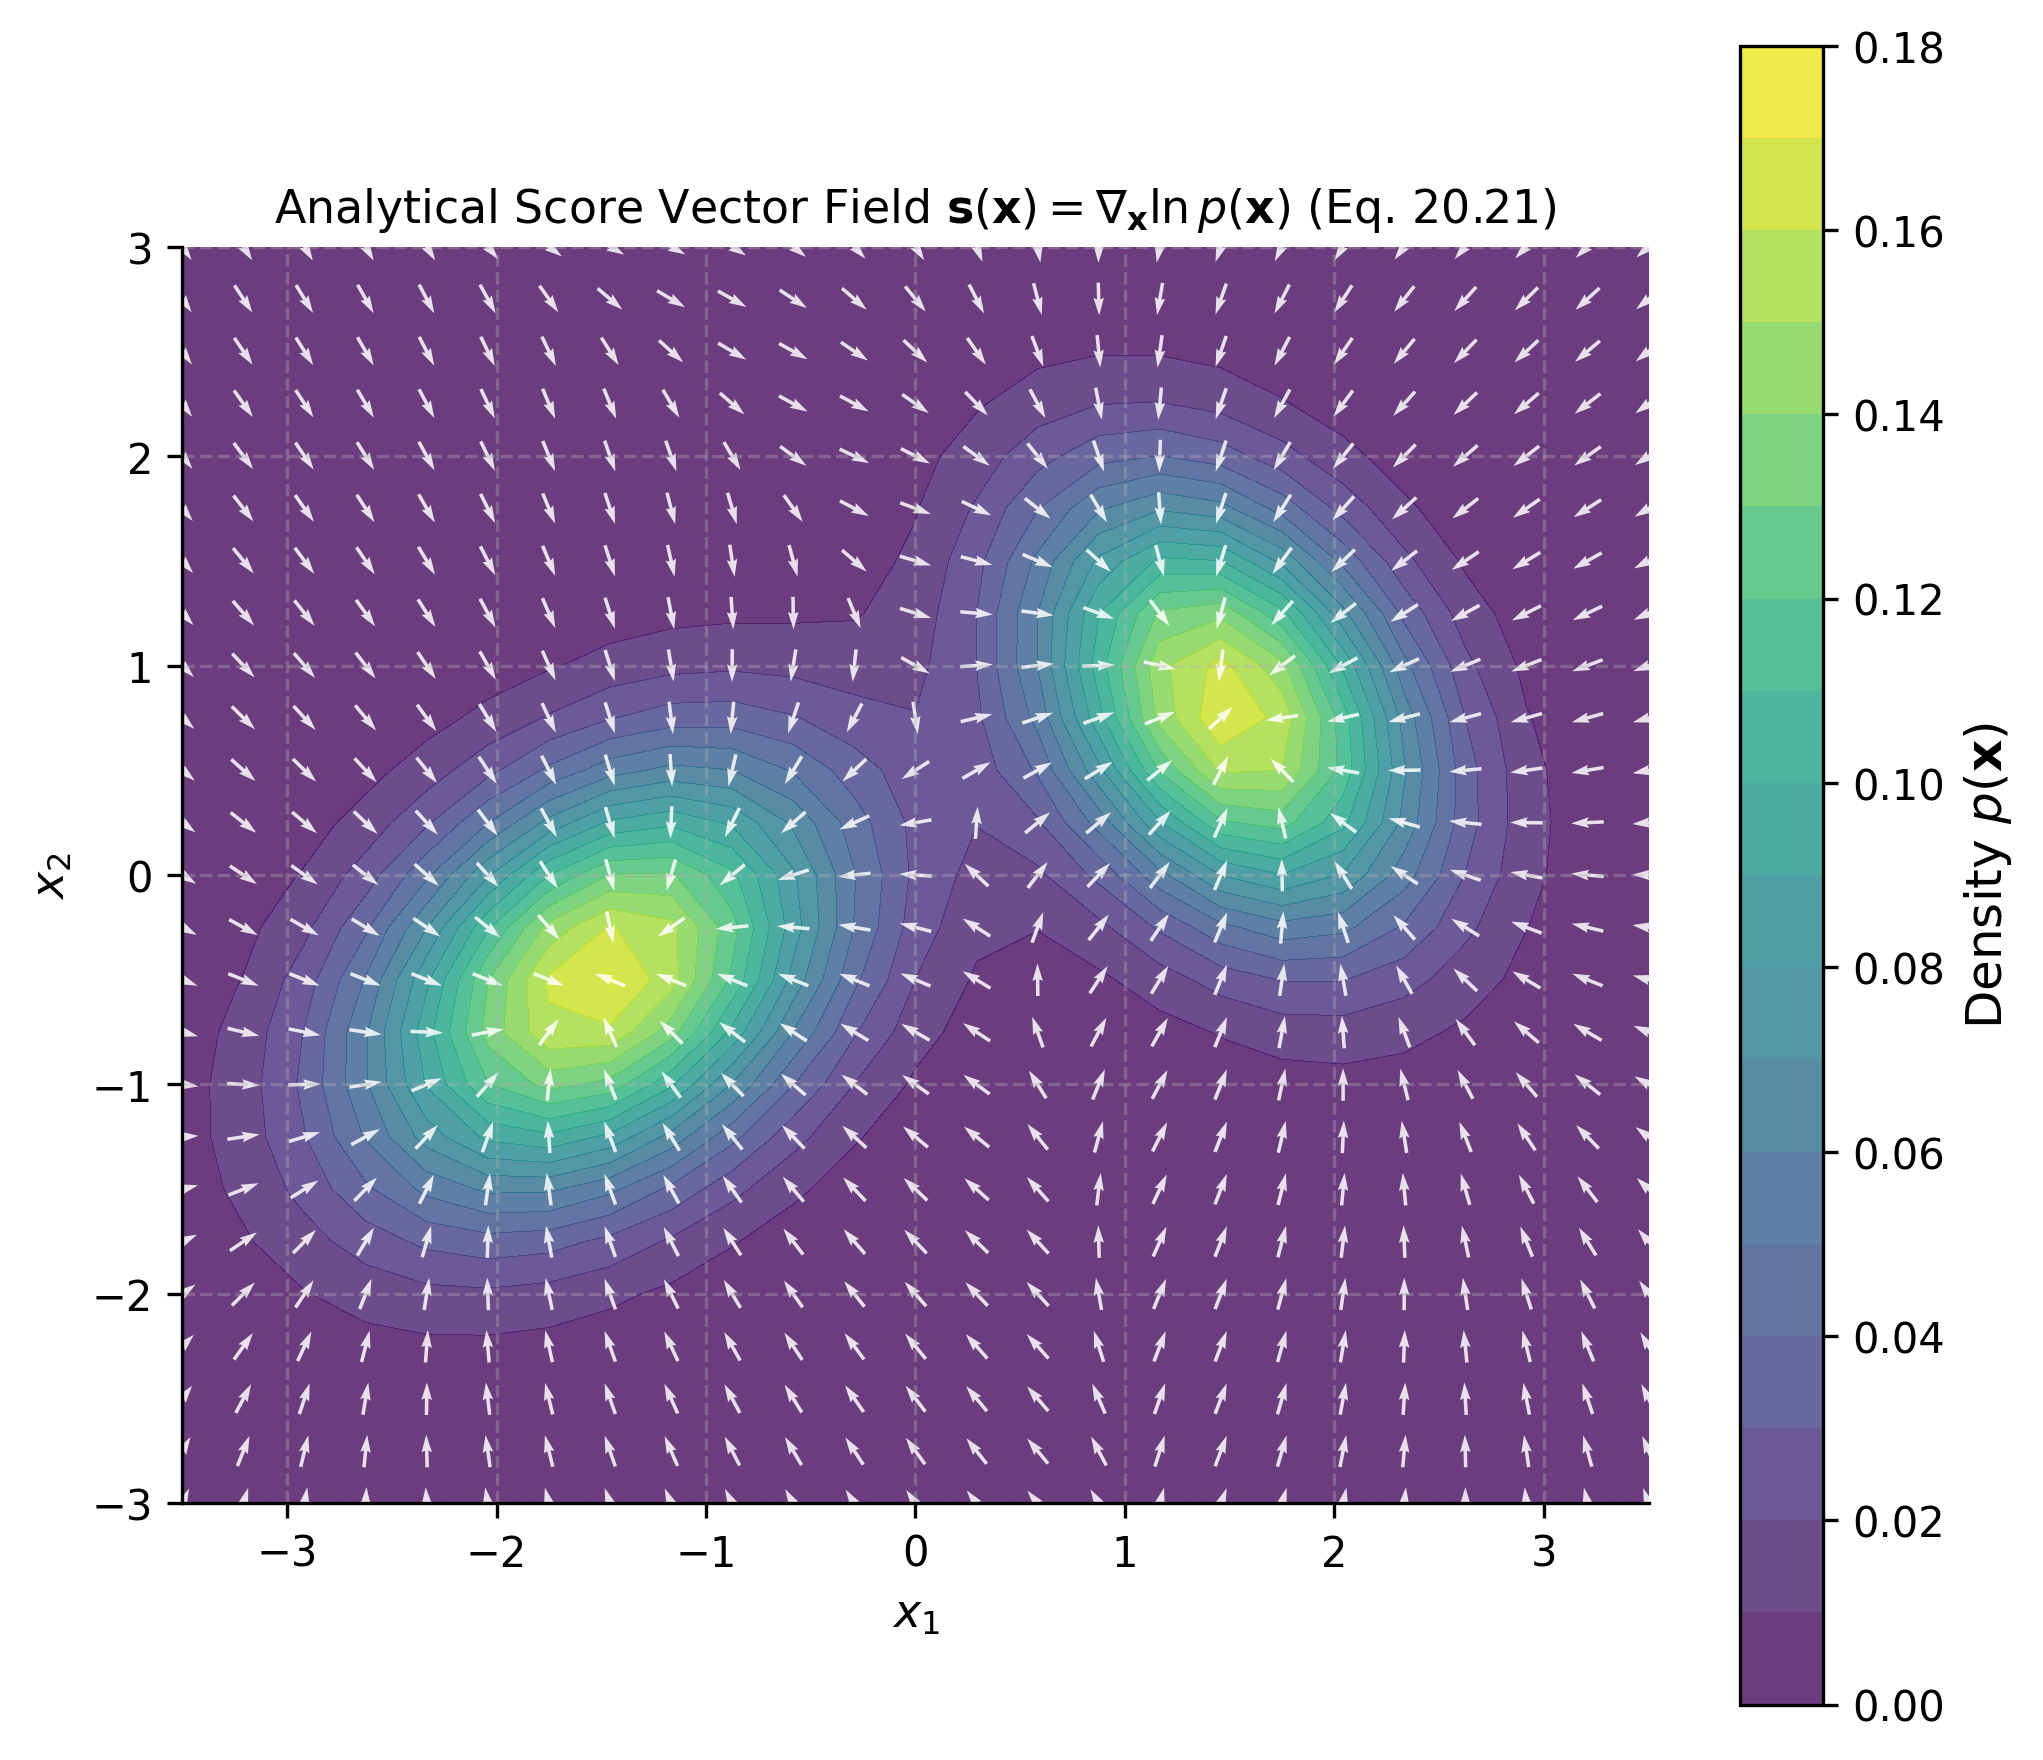

In [3]:
# 2次元混合ガウス分布の真のスコアベクトル場と確率密度の可視化 (式 20.21)
weights = [0.55, 0.45]
means = [[-1.5, -0.5], [1.5, 0.8]]
covs = [
    [[0.6, 0.2], [0.2, 0.5]],
    [[0.4, -0.15], [-0.15, 0.5]],
]
gmm = GaussianMixture2D(weights=weights, means=means, covs=covs)

fig = plot_score_vector_field_and_mixture(gmm, xlim=(-3.5, 3.5), ylim=(-3, 3), grid_size=25)
plt.show()


---

### 20.3.2 修正スコア損失 (Modified score loss)

陰的スコアマッチング (20.23) はヤコビ行列の対角和 $\operatorname{Tr}(\nabla \mathbf{s})$ を必要とし、高次元画像（数万次元）では逆伝播計算が極めて高コストになります。
これを解決したのが Vincent (2011) による**デノイジングスコアマッチング（Denoising Score Matching: DSM）**です。

データ $\mathbf{x}$ にガウスノイズを付加した摂動データ $\tilde{\mathbf{x}}$ を考えます：
$$
q(\tilde{\mathbf{x}} \mid \mathbf{x}) = \mathcal{N}(\tilde{\mathbf{x}} \mid \mathbf{x}, \sigma^2 \mathbf{I}) \tag{20.24}
$$
この条件付き分布のスコアは解析的に容易に計算できます：
$$
\nabla_{\tilde{\mathbf{x}}} \ln q(\tilde{\mathbf{x}} \mid \mathbf{x}) = -\frac{\tilde{\mathbf{x}} - \mathbf{x}}{\sigma^2} \tag{20.25}
$$
デノイジングスコアマッチングの目的関数は以下のように定義されます：
$$
J_{\text{denoising}}(\mathbf{w}) = \frac{1}{2} \mathbb{E}_{\mathbf{x} \sim p(\mathbf{x}), \tilde{\mathbf{x}} \sim q(\tilde{\mathbf{x}}\mid\mathbf{x})}\left[ \left\| \mathbf{s}(\tilde{\mathbf{x}}, \mathbf{w}) - \nabla_{\tilde{\mathbf{x}}} \ln q(\tilde{\mathbf{x}}\mid\mathbf{x}) \right\|^2 \right] \tag{20.26}
$$

Vincent (2011) は、この目的関数を最小化する最適モデル $\mathbf{s}^*(\tilde{\mathbf{x}})$ が、ノイズ重畳後の真の周辺スコア $\nabla_{\tilde{\mathbf{x}}} \ln q(\tilde{\mathbf{x}})$（ただし $q(\tilde{\mathbf{x}}) = \int p(\mathbf{x}) q(\tilde{\mathbf{x}}\mid\mathbf{x}) d\mathbf{x}$）に厳密に一致することを証明しました。

#### 拡散モデルとの決定的一致
前向き拡散ステップ $\mathbf{z}_t = \sqrt{\bar{\alpha}_t}\mathbf{x} + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}$ において、条件付きスコアは：
$$
\nabla_{\mathbf{z}_t} \ln q(\mathbf{z}_t \mid \mathbf{x}) = -\frac{\mathbf{z}_t - \sqrt{\bar{\alpha}_t}\mathbf{x}}{1 - \bar{\alpha}_t} = -\frac{\boldsymbol{\epsilon}}{\sqrt{1 - \bar{\alpha}_t}}
$$
したがって、**拡散モデルのノイズ予測器 $\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)$ は、スケール係数を除いてスコア関数 $\mathbf{s}_\theta(\mathbf{z}_t, t)$ と厳密に等価**です：
$$
\mathbf{s}_\theta(\mathbf{z}_t, t) = -\frac{\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)}{\sqrt{1 - \bar{\alpha}_t}}
$$


---

### 20.3.3 ノイズ分散 (Noise variance) と焼きなましランジュバン動力学

#### 1. 低密度領域問題と多重ノイズレベル
訓練データが存在しない空間の低密度領域では、スコア関数を正確に推定することが原理的に困難です。
Song & Ermon (2019) (NCSN) は、複数のノイズレベル $\sigma_1 < \sigma_2 < \dots < \sigma_L$ を導入し、全空間をカバーする大きなノイズ $\sigma_L$ から微細な構造を捉える小さなノイズ $\sigma_1$ までを同時に学習する**ノイズ条件付きスコアネットワーク（Noise-Conditional Score Network）**を提案しました：

$$
\mathcal{L}(\theta) = \frac{1}{L} \sum_{i=1}^L \sigma_i^2 \mathbb{E}\left[ \left\| \mathbf{s}_\theta(\tilde{\mathbf{x}}, \sigma_i) + \frac{\tilde{\mathbf{x}} - \mathbf{x}}{\sigma_i^2} \right\|^2 \right] \tag{20.27}
$$

#### 2. 焼きなましランジュバン動力学 (Annealed Langevin Dynamics)
推論時には、最大ノイズ $\sigma_L$ から最小ノイズ $\sigma_1$ に向けて段階的にノイズレベルを下げながらランジュバンサンプリングを実行します：

$$
\mathbf{x}_{k+1} = \mathbf{x}_k + \frac{\alpha_i}{2} \mathbf{s}_\theta(\mathbf{x}_k, \sigma_i) + \sqrt{\alpha_i} \boldsymbol{\epsilon}_k \tag{20.28}
$$


---

### 20.3.4 確率微分方程式 (Stochastic differential equations)

Song et al. (2021) は、拡散モデル（DDPM）とスコアベースモデル（NCSN）を連続時間極限（$T \to \infty$）における伊藤の**確率微分方程式（Itô SDE）**として統一しました。

#### 1. 前向き確率微分方程式 (Forward SDE)
$$
d\mathbf{z} = \mathbf{f}(\mathbf{z}, t) dt + g(t) d\mathbf{w} \tag{20.29}
$$
- **VP SDE (Variance Preserving, DDPM の連続極限)**:
  $$
  \mathbf{f}(\mathbf{z}, t) = -\frac{1}{2}\beta(t)\mathbf{z}, \qquad g(t) = \sqrt{\beta(t)}
  $$
- **VE SDE (Variance Exploding, NCSN の連続極限)**:
  $$
  \mathbf{f}(\mathbf{z}, t) = \mathbf{0}, \qquad g(t) = \sqrt{\frac{d[\sigma^2(t)]}{dt}}
  $$

#### 2. 逆時間確率微分方程式 (Reverse-time SDE: Anderson 1982)
前向き SDE を時間反転した逆生成プロセスは、厳密に以下の逆時間 SDE で記述されます：

$$
d\mathbf{z} = \left[ \mathbf{f}(\mathbf{z}, t) - g(t)^2 \nabla_{\mathbf{z}} \ln p_t(\mathbf{z}) \right] dt + g(t) d\bar{\mathbf{w}} \tag{20.30}
$$

ここで $dt$ は時間 $t = T$ から $t = 0$ への負の微小増分であり、$\bar{\mathbf{w}}$ は逆向き標準ブラウン運動です。逆プロセスのドリフト項を計算するためには、**スコア関数 $\nabla_{\mathbf{z}} \ln p_t(\mathbf{z})$ のみが分かれば十分である**という驚くべき結論が得られます。

#### 3. 確率流常微分方程式 (Probability Flow ODE, 式 20.31)
すべての拡散 SDE に対し、各時刻 $t$ における周辺確率密度 $p_t(\mathbf{z})$ の時間発展が厳密に一致する**決定論的な常微分方程式（Probability Flow ODE）**が存在します：

$$
\frac{d\mathbf{z}}{dt} = \mathbf{f}(\mathbf{z}, t) - \frac{1}{2} g(t)^2 \nabla_{\mathbf{z}} \ln p_t(\mathbf{z}) \tag{20.31}
$$

この発見により：
1. ランダムノイズを注入することなく、ルンゲ・クッタ法等の高精度数値 ODE ソルバーを用いて高速にサンプリングが可能になります。
2. 第18章で学んだ連続時間正規化フロー（Continuous Normalizing Flows）の瞬時変数変換公式（式 18.27）をそのまま適用し、**任意のデータに対する厳密な対数尤度 $\ln p(\mathbf{x})$ の正確な評価**が可能になります。


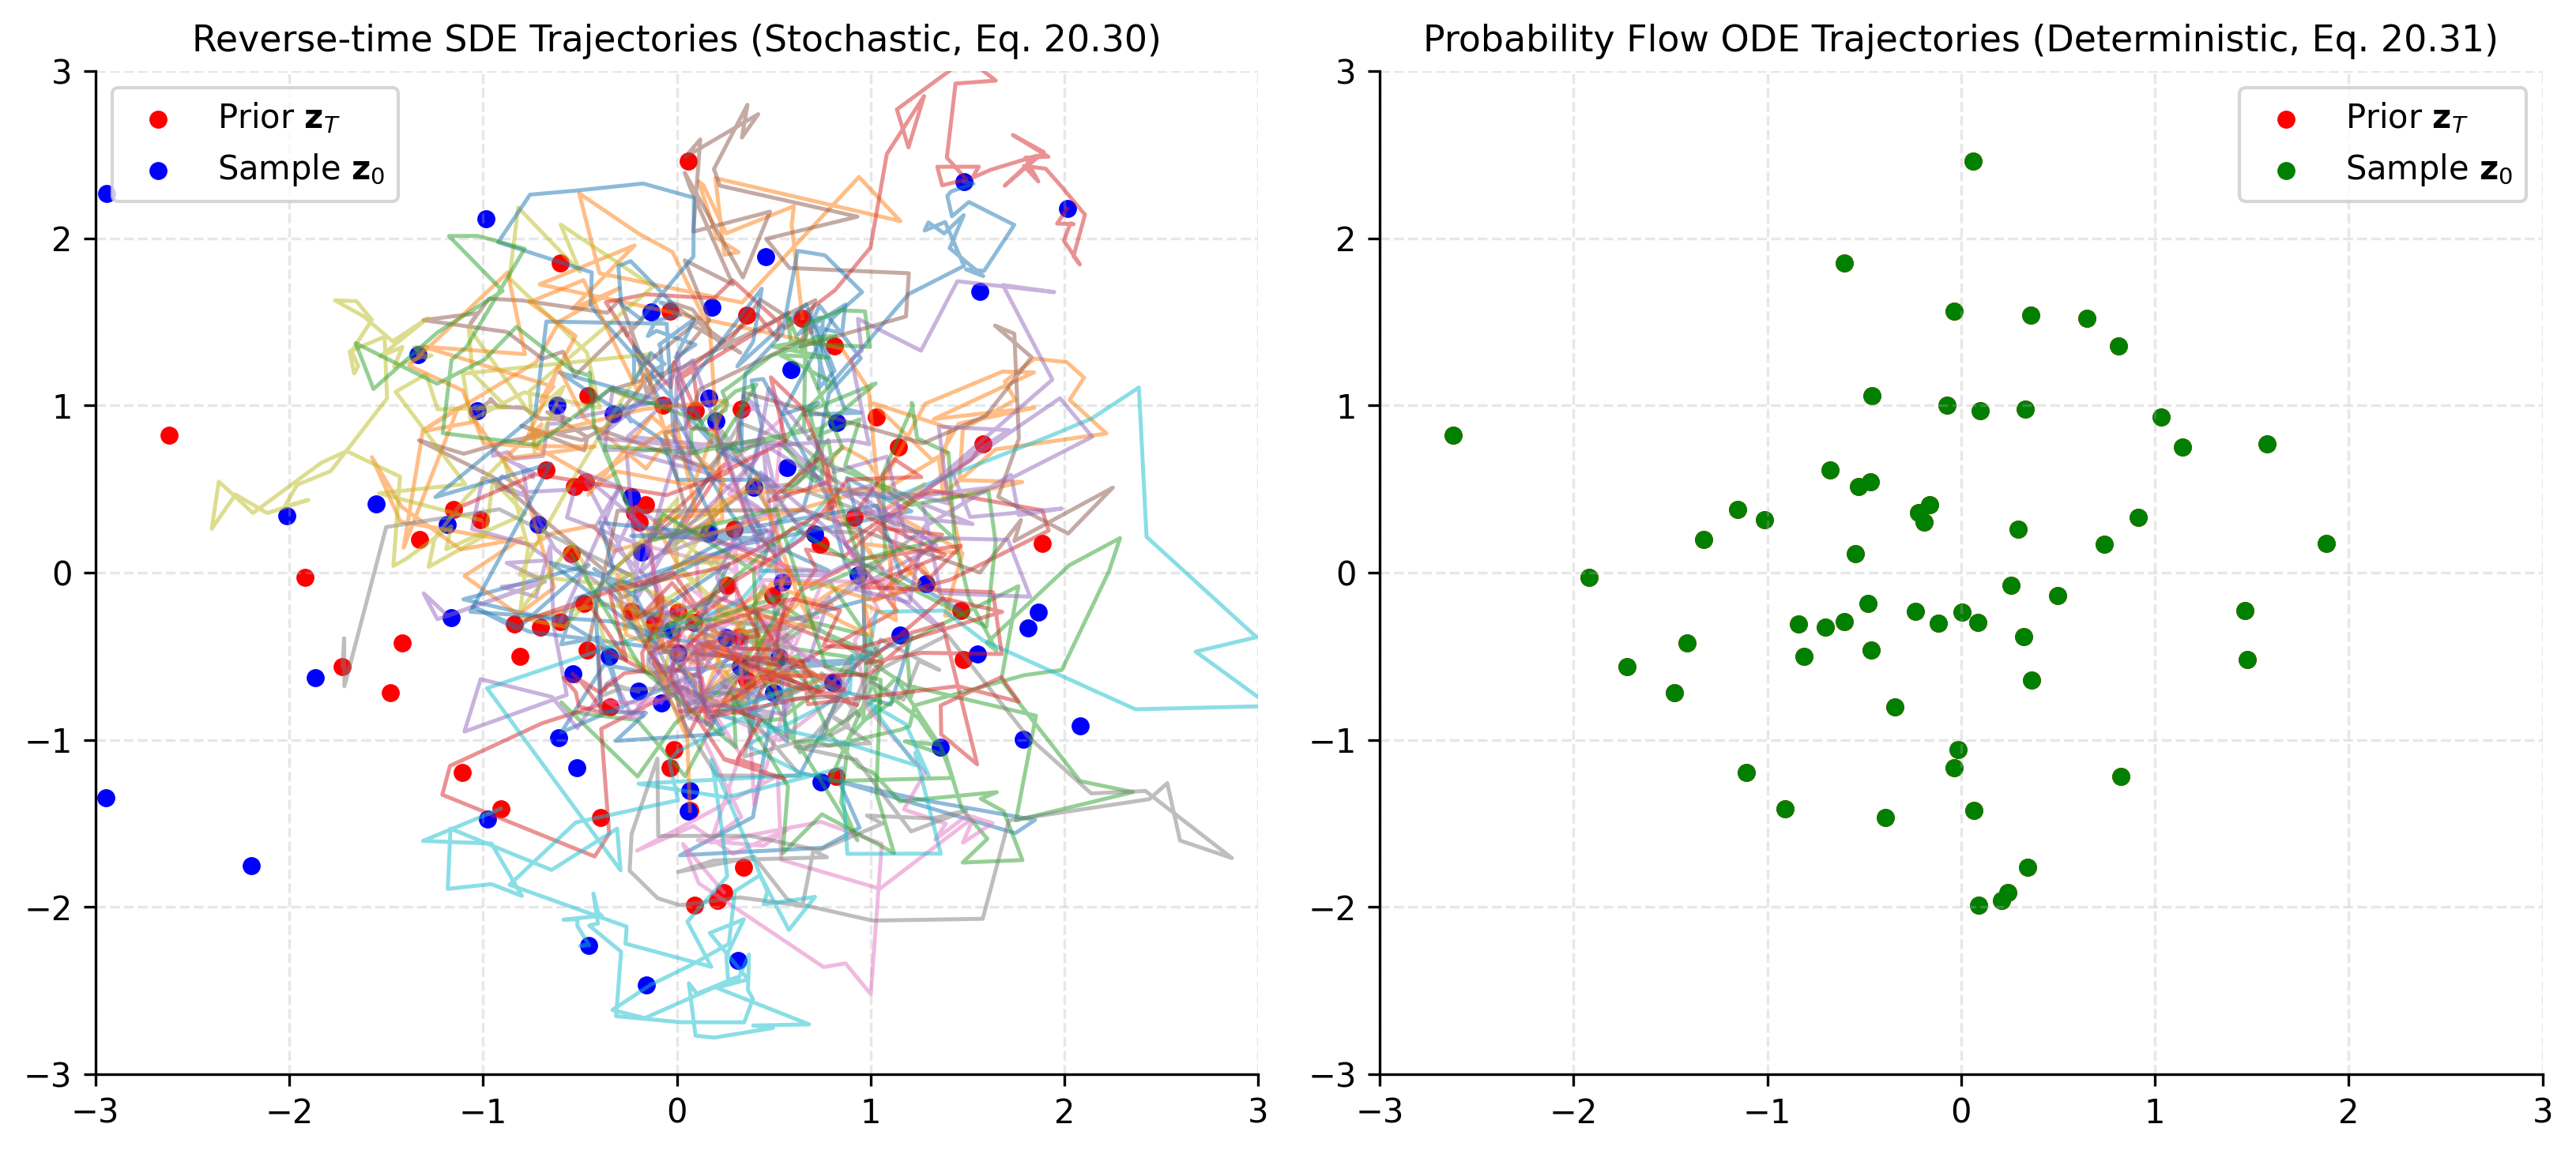

In [4]:
# 連続時間 VP SDE と Probability Flow ODE による逆時間サンプリングの比較
sde = VPSDE(beta_min=0.1, beta_max=15.0)

# 標準正規事前分布 z_T ~ N(0, I) からの初期サンプリング
rng = np.random.RandomState(42)
N_sim = 60
z_T = rng.randn(N_sim, 2)

# トイ目標スコア: 原点中心の標準ガウス目標
def toy_score_t(z, t):
    # 連続時間における理想スコア
    return -z

# 逆時間シミュレーション (t = 1.0 -> 0.0)
n_steps = 100
dt = 1.0 / n_steps
time_steps = np.linspace(1.0, 0.0, n_steps + 1)

z_sde = z_T.copy()
z_ode = z_T.copy()

sde_traj = [z_sde.copy()]
ode_traj = [z_ode.copy()]

for i in range(n_steps):
    t_curr = time_steps[i]
    score_curr = toy_score_t(z_sde, t_curr)
    score_ode = toy_score_t(z_ode, t_curr)

    z_sde = sde.reverse_sde_step(z_sde, score_curr, t=t_curr, dt=dt)
    z_ode = sde.probability_flow_ode_step(z_ode, score_ode, t=t_curr, dt=dt)

    sde_traj.append(z_sde.copy())
    ode_traj.append(z_ode.copy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=300)

# SDE 軌跡
sde_traj = np.array(sde_traj)
for k in range(min(15, N_sim)):
    ax1.plot(sde_traj[:, k, 0], sde_traj[:, k, 1], alpha=0.5, lw=1.2)
ax1.scatter(sde_traj[0, :, 0], sde_traj[0, :, 1], color='red', s=20, label=r'Prior $\mathbf{z}_T$')
ax1.scatter(sde_traj[-1, :, 0], sde_traj[-1, :, 1], color='blue', s=20, label=r'Sample $\mathbf{z}_0$')
ax1.set_title("Reverse-time SDE Trajectories (Stochastic, Eq. 20.30)", fontsize=11)
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Probability Flow ODE 軌跡
ode_traj = np.array(ode_traj)
for k in range(min(15, N_sim)):
    ax2.plot(ode_traj[:, k, 0], ode_traj[:, k, 1], alpha=0.6, lw=1.5)
ax2.scatter(ode_traj[0, :, 0], ode_traj[0, :, 1], color='red', s=20, label=r'Prior $\mathbf{z}_T$')
ax2.scatter(ode_traj[-1, :, 0], ode_traj[-1, :, 1], color='green', s=20, label=r'Sample $\mathbf{z}_0$')
ax2.set_title("Probability Flow ODE Trajectories (Deterministic, Eq. 20.31)", fontsize=11)
ax2.set_xlim(-3, 3)
ax2.set_ylim(-3, 3)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 20.3 節のまとめ (Section Summary)

本節では、スコアマッチングと連続時間確率微分方程式（SDE）の理論的枠組みを体系的に理解しました：

1. **スコア関数と正規化定数の不問性 (式 20.21 〜 20.23)**:
   - スコア関数 $\nabla_{\mathbf{x}} \ln p(\mathbf{x})$ は分配関数 $Z$ を必要としないため、未正規化モデルの学習に最適です。
   - 陰的スコアマッチングは部分積分により真のスコアを用いずに学習可能ですが、高次元ではヤコビ行列の対角和計算がボトルネックとなります。

2. **デノイジングスコアマッチング (式 20.24 〜 20.26)**:
   - ノイズ重畳条件付き分布の解析的スコア $-\frac{\boldsymbol{\epsilon}}{\sigma}$ を目標とすることで、ヤコビアン不要の効率的な二次損失が得られます。
   - これにより、離散拡散モデルのノイズ予測 $\boldsymbol{\epsilon}_\theta$ とスコア推定 $\mathbf{s}_\theta$ が数学的に表裏一体であることが解明されました。

3. **連続時間 SDE と確率流 ODE の統一 (式 20.29 〜 20.31)**:
   - 前向き拡散は伊藤 SDE として記述され、その逆時間 SDE はドリフト項にスコア関数を組み込むだけで厳密に定式化されます。
   - 確率流 ODE（Probability Flow ODE）は SDE と同一の周辺確率軌道を決定論的に追従し、高速サンプリングと厳密な尤度評価を可能にします。
